#**nalara.academy**

## **Modul 3 - Exploratory Data Analysis (EDA)**
### **📌Pengantar Modul**
Banyak pemula di bidang Machine Learning terburu-buru memasukkan data ke dalam arsitektur AI tanpa memahami kondisi aset yang mereka miliki. Di dunia Computer Vision, data kita bukanlah baris angka di dalam tabel Excel, melainkan ribuan file gambar yang tersebar di berbagai direktori. Jika data mentah ini langsung digunakan untuk melatih AI, model yang dihasilkan berisiko tinggi mengalami crash, bias, atau gagal mengenali objek di dunia nyata.

Modul ini didesain khusus untuk melatih intuisi dan cara berpikir Anda sebagai Data Analyst/Developer sebelum melangkah ke tahap pemodelan Deep Learning. Kita akan berfokus pada teknik eksplorasi visual murni dengan memanfaatkan kombinasi tools industri seperti `os`, `glob`, `OpenCV`, `NumPy`, dan `Matplotlib`.

### **🗺️ Peta Perjalanan Belajar (Learning Roadmap)**
* 📁 Sesi 1: Menggali Struktur Data (Navigasi Direktori)
  * Fokus: Memahami manajemen folder sebagai database identitas gambar (label kelas) dan menguasai konsep pembagian data (Train, Validation, Test split) demi validasi model yang jujur.
  * Output Praktis: Peserta mampu bernavigasi di dalam sistem komputer secara programatis dan melakukan random sampling untuk inspeksi visual cepat.
* 📊 Sesi 2: Mencegah Bias AI (Class Imbalance)
  * Fokus: Mendeteksi ketimpangan jumlah data antar kelas gambar yang dapat memicu Paradoks Akurasi, yaitu kondisi di mana AI terlihat pintar di atas kertas tapi sebenarnya tidak adil dan bias di lapangan.
  * Output Praktis: Mampu mengekstrak distribusi jumlah data dan menyajikannya ke dalam grafik batang (Bar Chart) yang informatif menggunakan `Matplotlib` dan `Seaborn`.
* 📏 Sesi 3: Analisis Dimensi & Rasio Aspek Gambar
  * Fokus: Mengidentifikasi variasi resolusi gambar (lebar dan tinggi) dari berbagai sumber guna menghindari risiko Squashing (objek menjadi gepeng/terdistorsi) saat proses penyeragaman ukuran (resize).
  * Output Praktis: Mampu memetakan sebaran dimensi gambar lewat grafik Scatter Plot untuk menentukan resolusi input model AI yang paling optimal.
* 🗑️ Sesi 4: Deteksi Kualitas "Sampah" Visual & Pipeline Pembersihan
  * Fokus: Menerapkan prinsip "Garbage In, Garbage Out" dengan menyaring file gambar yang corrupt (rusak) serta anomali visual (terlalu gelap/blank) yang berpotensi menghentikan proses training secara tiba-tiba.
  * Output Praktis: Membangun Mini Project berupa skrip pembersih dataset otomatis menggunakan mekanisme Try-Except dan komputasi matriks NumPy.

💡 **Prinsip Utama Modul Ini**: > "Sebelum kita mengajarkan kecerdasan buatan (AI) cara melihat, kita harus menjadi mata yang teliti bagi AI itu sendiri."

### **📦 Dataset: Kucing dan Anjing**
Dataset yang digunakan dalam modul ini adalah kumpulan gambar **kucing** dan **anjing**
yang telah dibagi ke dalam tiga split siap pakai: Train, Validation, dan Test.

| Info | Detail |
|------|--------|
| 📌 Sumber | Kaggle |
| 👤 Author | citranurjanah |
| 🔗 Link | https://www.kaggle.com/datasets/citranurjanah/kucing-dan-anjing-uas-ai |
| 🗂️ Kelas | Kucing, Anjing |
| ✂️ Split | Train / Validation / Test |

---

#### **⬇️ Cara Mengunduh Dataset**
Dataset telah disediakan dan dapat diunduh langsung melalui Google Drive.
Jalankan cell di bawah ini untuk mengunduh dan mengekstrak dataset secara otomatis.

> 💡 **Catatan**: Kamu tidak perlu membuat akun Kaggle atau API token apapun.
> Cukup jalankan cell di bawah dan dataset siap digunakan.

In [ ]:
FILE_ID = "1T6M_whqoGsrEtY7AHoUI-eKTeB1ZgCLp"

!gdown --id {FILE_ID} -O /content/dataset.zip

import zipfile
with zipfile.ZipFile("/content/dataset.zip", "r") as z:
    z.extractall("/content/dataset")

print("✅ Dataset berhasil diekstrak!")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1T6M_whqoGsrEtY7AHoUI-eKTeB1ZgCLp
From (redirected): https://drive.google.com/uc?id=1T6M_whqoGsrEtY7AHoUI-eKTeB1ZgCLp&confirm=t&uuid=6c5fdcad-9eda-44a5-bfe2-723dc4eeea47
To: /content/dataset.zip
100% 234M/234M [00:03<00:00, 70.6MB/s]
✅ Dataset berhasil diekstrak!


### **📂 Sesi 1: Menggali Struktur Data (Navigasi Direktori)**

#### **Konsep "Folder adalah Database"**



Jika di data teks (seperti Excel) kita melihat kolom Nama, Umur, dan Pekerjaan, lalu bagaimana cara komputer tahu identitas sebuah gambar? Apakah komputer otomatis tahu kalau itu gambar kucing? Tentu tidak.

Di dunia Computer Vision, struktur folder adalah cara kita memberikan label (tag) ke data. Ketika kita merapikan folder seperti ini:

*   Folder `Kucing/` $\rightarrow$ berisi 500 foto kucing.
*   Folder `Anjing/` $\rightarrow$ berisi 500 foto anjing.

Nama folder tersebut berfungsi sebagai Primary Key atau Label di database. Saat melatih AI nanti, kode program kita akan membaca nama folder ini dan menjadikannya target tebakan (kelas). Jika manajemen foldernya berantakan (misal ada foto anjing nyelip di folder kucing), maka AI kita akan belajar dari informasi yang salah. Itu kenapa eksplorasi direktori menjadi langkah awal yang super krusial.

##### **💻 Praktik 1: Navigasi Folder & Menghitung Total File Gambar**


Di sini kita akan belajar menjadi "penjelajah" sistem file menggunakan Python.
Alih-alih membuka File Explorer secara manual, kita akan memerintahkan Python
untuk masuk ke dalam folder, melihat isinya, dan menghitung berapa banyak file
gambar yang ada — semuanya secara otomatis dan programatis.

Library yang digunakan:
- `os` → untuk bernavigasi di dalam struktur folder (seperti `cd` di Terminal)
- `glob` → untuk mencari file berdasarkan pola ekstensi (misal: semua file `.jpg`)

In [ ]:
# Importasi library yang digunakan
import os
import glob

In [ ]:
# Path dari dataset
DATASET_PATH = "/content/dataset"

# Ekstensi gambar yang akan dicari
IMAGE_EXTENSIONS = ["*.jpg", "*.jpeg", "*.png", "*.webp"]

In [ ]:
# Method untuk menghitung gambar
def hitung_gambar_dalam_folder(path_folder):
    """
    Menghitung total file gambar di dalam sebuah folder (tidak rekursif).
    Mengembalikan jumlah total gambar yang ditemukan.
    """
    total = 0
    for ekstensi in IMAGE_EXTENSIONS:
        ditemukan = glob.glob(os.path.join(path_folder, ekstensi))
        total += len(ditemukan)
    return total

In [ ]:
# Method untuk melihat struktur sekaligus memanggil method hitung
def eksplorasi_struktur_dataset(path_root):
    """
    Menjelajahi seluruh struktur dataset secara rekursif.
    Mencetak nama setiap folder dan jumlah gambar di dalamnya.
    """
    print(f"📁 Root Dataset : {path_root}")
    print("=" * 50)

    total_semua = 0

    # os.walk() akan masuk ke setiap subfolder secara otomatis
    for direktori, subdir, files in os.walk(path_root):

        # Hitung gambar di direktori saat ini
        jumlah = hitung_gambar_dalam_folder(direktori)

        if jumlah > 0:
            # Buat indentasi agar tampilan rapi seperti pohon folder
            level  = direktori.replace(path_root, "").count(os.sep)
            indent = "    " * level + "├── "

            nama_folder = os.path.basename(direktori)
            print(f"{indent}{nama_folder}/  →  {jumlah} gambar")
            total_semua += jumlah

    print("=" * 50)
    print(f"📊 Total keseluruhan : {total_semua} gambar")

In [ ]:
# Jalankan eksplorasi
eksplorasi_struktur_dataset(DATASET_PATH)

📁 Root Dataset : /content/dataset
        ├── kucing/  →  4126 gambar
        ├── anjing/  →  4136 gambar
        ├── kucing/  →  1116 gambar
        ├── anjing/  →  1167 gambar
📊 Total keseluruhan : 10545 gambar


#### **Pembagian Data (Dataset Splitting)**





Kita tidak boleh menggunakan seluruh gambar hanya untuk melatih AI. Kita harus membaginya menjadi beberapa bagian agar bisa menguji apakah AI beneran pintar atau cuma menghafal data latihan (overfitting).

*   **Train Dataset (~70-80%): "Buku Latihan Soal"**. Data utama yang dilihat dan dipelajari oleh AI untuk mengenali pola visual (misal: bentuk telinga, tekstur bulu).
*   **Validation Dataset (~10-15%): "Try Out"**. Digunakan selama proses latihan untuk mengecek performa AI secara berkala. Membantu kita tahu kapan AI salah arah sebelum ujian akhir.
*   **Test Dataset (~10-15%): "Ujian Nasional"**. Data yang tidak boleh diintip sama sekali oleh AI saat latihan. Hanya dikeluarkan di akhir untuk menguji performa asli AI di dunia nyata.

##### **💻 Praktik 2: Eksplorasi Pembagian Data (Train/Val/Test Split)**


Setelah tahu total gambar keseluruhan, sekarang kita akan membedah lebih dalam —
berapa persen data yang dialokasikan untuk Train, Validation, dan Test?

Kita akan membuat laporan otomatis yang menampilkan:
- Jumlah gambar per split (Train/Val/Test)
- Jumlah gambar per kelas di dalam setiap split
- Persentase pembagian data secara keseluruhan

In [ ]:
# Nama folder split yang akan kita cari di dalam dataset
split_folders = ["train_dataset", "valid_dataset", "test_dataset"]

# Coba akses salah satu split untuk melihat nama kelas yang tersedia
contoh_split = os.path.join(DATASET_PATH, "train_dataset")

kelas_list = sorted([
    d for d in os.listdir(contoh_split)
    if os.path.isdir(os.path.join(contoh_split, d))
])

print(f"✅ Split yang akan dianalisis : {split_folders}")
print(f"✅ Kelas yang ditemukan       : {kelas_list}")

✅ Split yang akan dianalisis : ['train_dataset', 'valid_dataset', 'test_dataset']
✅ Kelas yang ditemukan       : ['anjing', 'kucing']


In [ ]:
# Dictionary untuk menyimpan hasil hitungan
hasil = {}

for split in split_folders:
    path_split = os.path.join(DATASET_PATH, split)

    if not os.path.exists(path_split):
        print(f"⚠️  Folder '{split}' tidak ditemukan, dilewati.")
        continue

    hasil[split] = {}
    total_split = 0

    for kelas in kelas_list:
        path_kelas = os.path.join(path_split, kelas)
        jumlah = hitung_gambar_dalam_folder(path_kelas)
        hasil[split][kelas] = jumlah
        total_split += jumlah

    hasil[split]["__total__"] = total_split

# Cek hasil sementara
for split, data in hasil.items():
    print(f"📂 {split.upper():10} → {data}")

⚠️  Folder 'valid_dataset' tidak ditemukan, dilewati.
📂 TRAIN_DATASET → {'anjing': 4136, 'kucing': 4126, '__total__': 8262}
📂 TEST_DATASET → {'anjing': 1167, 'kucing': 1116, '__total__': 2283}


In [ ]:
# Cetak laporan dataset
total_dataset = sum(data["__total__"] for data in hasil.values())

print("=" * 55)
print(f"{'LAPORAN PEMBAGIAN DATASET':^55}")
print("=" * 55)

for split, data in hasil.items():
    total_split = data["__total__"]
    persen = (total_split / total_dataset * 100) if total_dataset > 0 else 0

    print(f"\n📂 {split.upper()}  —  {total_split} gambar  ({persen:.1f}%)")
    print(f"   {'─' * 40}")

    for kelas, jumlah in data.items():
        if kelas == "__total__":
            continue
        persen_kelas = (jumlah / total_split * 100) if total_split > 0 else 0
        bar = "█" * int(persen_kelas / 5)
        print(f"   {kelas:<15} {jumlah:>5} gambar  {bar} {persen_kelas:.1f}%")

print(f"\n{'=' * 55}")
print(f"  Total Dataset : {total_dataset} gambar")
print("=" * 55)

               LAPORAN PEMBAGIAN DATASET               

📂 TRAIN_DATASET  —  8262 gambar  (78.3%)
   ────────────────────────────────────────
   anjing           4136 gambar  ██████████ 50.1%
   kucing           4126 gambar  █████████ 49.9%

📂 TEST_DATASET  —  2283 gambar  (21.7%)
   ────────────────────────────────────────
   anjing           1167 gambar  ██████████ 51.1%
   kucing           1116 gambar  █████████ 48.9%

  Total Dataset : 10545 gambar


#### **Pengambilan Sampel Acak (Random Sampling)**



Saat melakukan EDA pada gambar, kita tidak bisa (dan tidak perlu) membuka ribuan gambar satu per satu secara manual. Kita cukup mengambil sampel kecil (misal: 9 gambar) untuk diinspeksi.

**Kenapa harus diacak (random)?**
Di dalam komputer, file biasanya tersusun rapi berdasarkan alfabet atau waktu. Jika kita hanya mengambil 9 gambar pertama di folder kucing/, bisa jadi yang muncul hanya kucing anggora putih semua (karena kebetulan namanya berawalan huruf 'A').

Mengambil sampel secara acak membantu kita mendapatkan representasi yang adil dan jujur dari keseluruhan isi dataset dalam sekali lihat.

##### **💻 Praktik 3: Random Sampling — Kolase 9 Gambar**


Kita tidak mungkin membuka ribuan gambar satu per satu untuk inspeksi visual.
Solusinya adalah **Random Sampling** — ambil sejumlah kecil gambar secara acak
sebagai representasi dari keseluruhan dataset.

Kenapa harus acak? Karena file di komputer tersusun alfabetis. Jika kita ambil
9 gambar pertama saja, bisa jadi yang muncul hanya satu jenis gambar yang
namanya berawalan huruf yang sama. Pengacakan memastikan sampel kita **adil
dan representatif**.

Library tambahan yang digunakan:
- `random` → untuk mengacak urutan list file
- `cv2` (OpenCV) → untuk membaca file gambar dari disk
- `matplotlib` → untuk menampilkan gambar sebagai kolase

In [ ]:
# Importasi library yang digunakan
import random
import cv2
import matplotlib.pyplot as plt

In [ ]:
# Pilih folder yang ingin di-sampling (bisa diganti ke "valid" atau "test")
SPLIT_SAMPLING  = "train_dataset"
KELAS_SAMPLING  = kelas_list[0]  # ambil kelas pertama, bisa diganti manual

path_sampling = os.path.join(DATASET_PATH, SPLIT_SAMPLING, KELAS_SAMPLING)

# Kumpulkan semua path gambar di folder tersebut
semua_gambar = []
for ekstensi in IMAGE_EXTENSIONS:
    semua_gambar += glob.glob(os.path.join(path_sampling, ekstensi))

print(f"📂 Folder  : {path_sampling}")
print(f"🖼️  Total gambar ditemukan : {len(semua_gambar)}")

📂 Folder  : /content/dataset/train_dataset/anjing
🖼️  Total gambar ditemukan : 4136


In [ ]:
# Ambil sampel secara acak
JUMLAH_SAMPEL = 9

# Pastikan jumlah sampel tidak melebihi total gambar yang tersedia
jumlah_ambil = min(JUMLAH_SAMPEL, len(semua_gambar))

# random.sample() mengambil sejumlah elemen tanpa pengulangan
sampel = random.sample(semua_gambar, jumlah_ambil)

print(f"✅ {jumlah_ambil} gambar berhasil dipilih secara acak:")
for i, path in enumerate(sampel, 1):
    print(f"   {i}. {os.path.basename(path)}")

✅ 9 gambar berhasil dipilih secara acak:
   1. anjing795.jpg
   2. anjing24.jpg
   3. anjing2264.jpg
   4. anjing4084.jpg
   5. anjing3445.jpg
   6. anjing2527.jpg
   7. anjing159.jpg
   8. anjing3316.jpg
   9. anjing3412.jpg


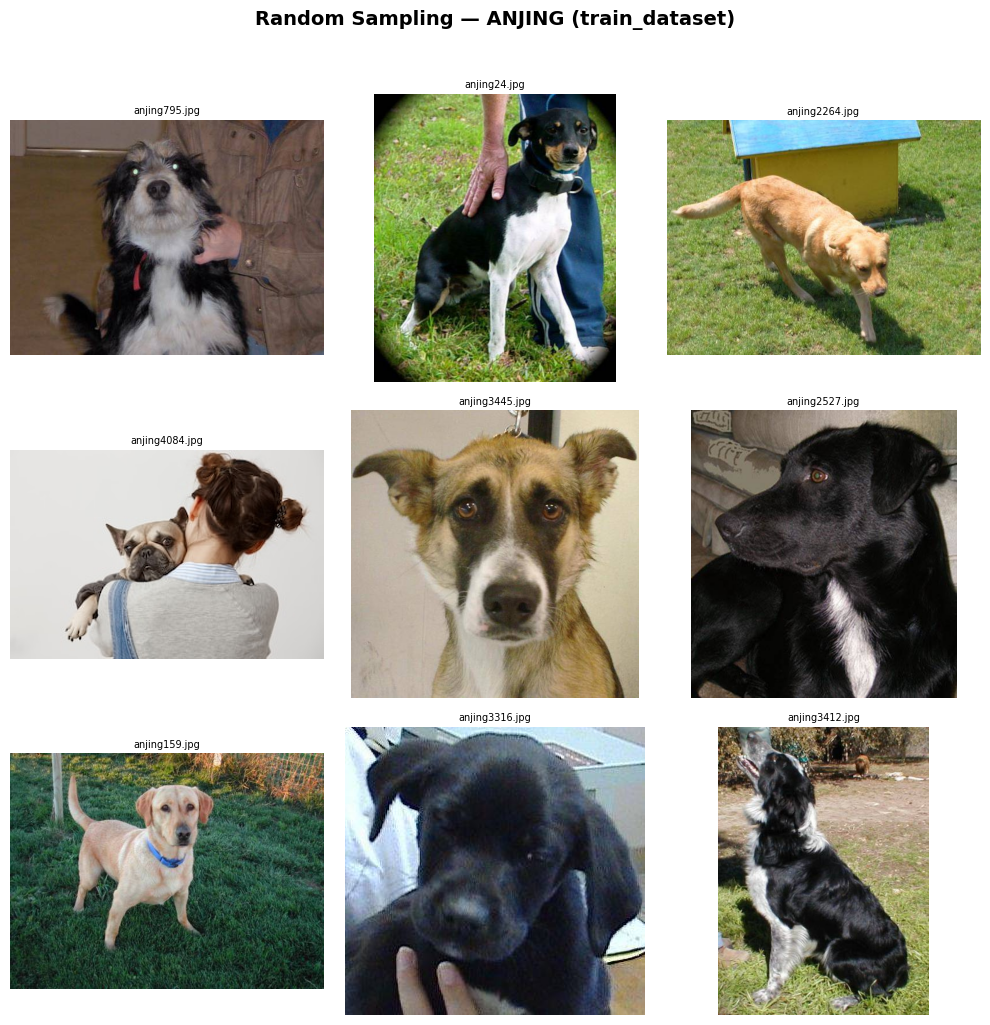

In [ ]:
# Visualisasikan 9 gambar tersebut
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle(
    f"Random Sampling — {KELAS_SAMPLING.upper()} ({SPLIT_SAMPLING})",
    fontsize=14, fontweight="bold", y=1.02
)

for i, ax in enumerate(axes.flatten()):
    if i < len(sampel):
        # OpenCV membaca gambar dalam format BGR, konversi ke RGB untuk Matplotlib
        img_bgr = cv2.imread(sampel[i])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        ax.imshow(img_rgb)
        ax.set_title(os.path.basename(sampel[i]), fontsize=7, pad=4)

    ax.axis("off")  # sembunyikan sumbu x dan y

plt.tight_layout()
plt.show()

### **📊 Sesi 2: Mencegah Bias AI (Class Imbalance)**

#### **Apa itu Class Imbalance?**




Class Imbalance (Ketidakseimbangan Kelas) adalah kondisi di mana jumlah sampel gambar antara satu kelas dengan kelas lainnya jomplang banget di dalam dataset.
Misalnya seperti ini:
* Dataset Sehat (Balanced): Kucing (500 gambar), Anjing (500 gambar).
* Dataset Sakit (Imbalanced): Kucing (900 gambar), Anjing (100 gambar).

Analogi: Jika kamu mengajari anak kecil dengan memberikan 90 foto kucing dan cuma 10 foto anjing, si anak bakal jago banget mengenali ciri-ciri kucing. Tapi begitu dikasih lihat foto anjing di dunia nyata, dia kemungkinan besar bakal bingung atau malah mengira itu kucing, karena dia jarang sekali melihat anjing selama belajar. AI pun sama; dia akan malas mempelajari kelas yang datanya terlalu sedikit.

**Paradoks Akurasi**

Banyak pemula bangga saat melihat akurasi model AI-nya tembus 90%. Padahal, angka 90% itu bisa jadi kebohongan besar jika datanya tidak seimbang.

**Contoh Kasus**: Kamu punya dataset sakit berisi 100 gambar: 90 gambar Kucing dan 10 gambar Anjing.

Jika AI kamu malas dan menebak "Semua gambar ini adalah Kucing!" tanpa menganalisis fitur piksel apa pun, AI tersebut otomatis tetap benar 90% (karena memang ada 90 gambar kucing di sana). Modelmu terlihat pintar di atas kertas, tapi kenyataannya AI ini 100% gagal dan tidak bisa mengenali anjing sama sekali.

Kesimpulan: Itulah mengapa kita wajib melakukan EDA dengan grafik batang (Bar Chart) untuk memastikan distribusi data kita adil sebelum melatih AI.

#### **Menghitung Jumlah Gambar**

##### **💻 Praktik 1: Menghitung Jumlah Gambar Per Kelas**

Sebelum membuat grafik, kita harus mengumpulkan datanya dulu secara terstruktur.
Di sini kita akan menghitung jumlah gambar untuk **setiap kelas** di **setiap split**
dan menyimpannya ke dalam sebuah dictionary agar mudah diolah di praktik berikutnya.

In [ ]:
# Dictionary utama untuk menyimpan distribusi kelas
# Struktur: { "train": { "kucing": 400, "anjing": 400 }, "valid": { ... }, ... }
distribusi = {}

for split in split_folders:
    path_split = os.path.join(DATASET_PATH, split)

    if not os.path.exists(path_split):
        continue

    distribusi[split] = {}

    for kelas in kelas_list:
        path_kelas = os.path.join(path_split, kelas)
        jumlah = hitung_gambar_dalam_folder(path_kelas)
        distribusi[split][kelas] = jumlah

# Cek hasil
print("📊 Distribusi Kelas Per Split:")
print("=" * 40)
for split, data in distribusi.items():
    print(f"\n🗂️  {split.upper()}")
    for kelas, jumlah in data.items():
        print(f"   {kelas:<15} : {jumlah} gambar")

📊 Distribusi Kelas Per Split:

🗂️  TRAIN_DATASET
   anjing          : 4136 gambar
   kucing          : 4126 gambar

🗂️  TEST_DATASET
   anjing          : 1167 gambar
   kucing          : 1116 gambar


In [ ]:
# Analisis class imbalance biasanya difokuskan ke split Train
# karena Train adalah data yang langsung dipelajari oleh AI
data_train = distribusi["train_dataset"]
total_train = sum(data_train.values())

print(f"📂 Analisis Split : TRAIN")
print(f"{'=' * 40}")
print(f"{'Kelas':<15} {'Jumlah':>8} {'Proporsi':>10}")
print(f"{'─' * 40}")

for kelas, jumlah in data_train.items():
    proporsi = (jumlah / total_train * 100) if total_train > 0 else 0
    print(f"{kelas:<15} {jumlah:>8} {proporsi:>9.1f}%")

print(f"{'─' * 40}")
print(f"{'Total':<15} {total_train:>8} {'100.0%':>10}")

📂 Analisis Split : TRAIN
Kelas             Jumlah   Proporsi
────────────────────────────────────────
anjing              4136      50.1%
kucing              4126      49.9%
────────────────────────────────────────
Total               8262     100.0%


#### **Visualisasi Distribusi Gambar**

##### **💻 Praktik 2: Visualisasi Distribusi Kelas dengan Bar Chart (Matplotlib)**


Angka di tabel tadi sudah cukup informatif, tapi otak manusia jauh lebih cepat
menangkap ketimpangan data lewat **visual** dibanding deretan angka.

Di sini kita akan mengubah data distribusi tadi menjadi **Bar Chart** menggunakan
Matplotlib — library visualisasi paling dasar dan fundamental di Python.

In [ ]:
# Importasi library yang digunakan
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Ambil data dari distribusi train yang sudah dihitung sebelumnya
kelas_label = list(data_train.keys())
jumlah_gambar = list(data_train.values())

print(f"✅ Label kelas  : {kelas_label}")
print(f"✅ Jumlah gambar: {jumlah_gambar}")

✅ Label kelas  : ['anjing', 'kucing']
✅ Jumlah gambar: [4136, 4126]


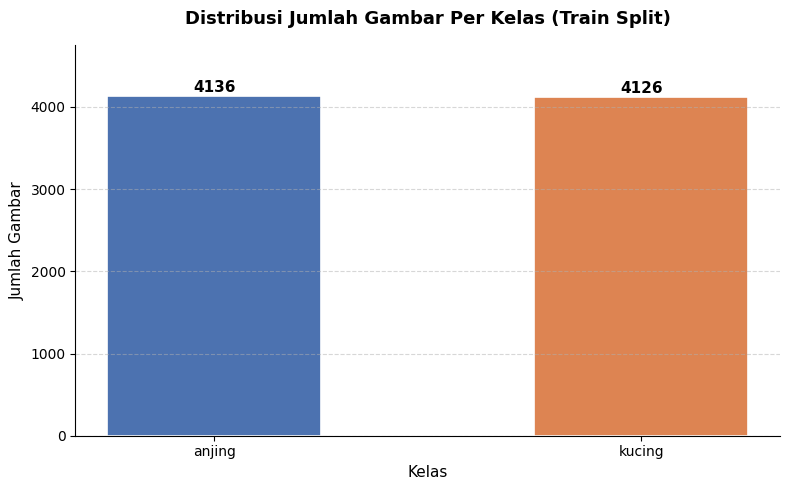

In [ ]:
# Tentukan ukuran barchart
fig, ax = plt.subplots(figsize=(8, 5))

# Buat bar chart
bars = ax.bar(
    kelas_label,
    jumlah_gambar,
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],  # warna per kelas
    width=0.5,
    edgecolor="white",
    linewidth=1.2
)

# Tambahkan angka di atas setiap bar
for bar, jumlah in zip(bars, jumlah_gambar):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posisi x (tengah bar)
        bar.get_height() + 5,               # posisi y (sedikit di atas bar)
        str(jumlah),
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

# Labeling
ax.set_title("Distribusi Jumlah Gambar Per Kelas (Train Split)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Kelas", fontsize=11)
ax.set_ylabel("Jumlah Gambar", fontsize=11)
ax.set_ylim(0, max(jumlah_gambar) * 1.15)  # beri ruang di atas bar
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)  # hapus border atas & kanan

plt.tight_layout()
plt.show()

In [ ]:
# Interpretasi hasil visualisasi
maks_kelas  = max(data_train, key=data_train.get)
min_kelas   = min(data_train, key=data_train.get)
rasio       = data_train[maks_kelas] / data_train[min_kelas]

print(f"📈 Kelas terbanyak : {maks_kelas} ({data_train[maks_kelas]} gambar)")
print(f"📉 Kelas tersedikit : {min_kelas} ({data_train[min_kelas]} gambar)")
print(f"⚖️  Rasio ketimpangan : {rasio:.2f}x")
print()

if rasio <= 1.5:
    print("✅ Dataset SEHAT — distribusi kelas cukup seimbang.")
elif rasio <= 3.0:
    print("⚠️  Dataset PERLU DIPERHATIKAN — ada ketimpangan ringan.")
else:
    print("❌ Dataset TIDAK SEHAT — ketimpangan kelas sangat signifikan!")
    print("   Pertimbangkan: augmentasi data, oversampling, atau tambah data.")

📈 Kelas terbanyak : anjing (4136 gambar)
📉 Kelas tersedikit : kucing (4126 gambar)
⚖️  Rasio ketimpangan : 1.00x

✅ Dataset SEHAT — distribusi kelas cukup seimbang.


##### **💻 Praktik 3: Visualisasi Lanjutan dengan Seaborn & Diskusi Dataset**


Bar Chart dari Matplotlib tadi sudah bagus, tapi tampilannya masih cukup polos.
Di praktik ini kita akan membuat visualisasi yang lebih **informatif dan estetik**
menggunakan **Seaborn**, yaitu library visualisasi berbasis Matplotlib yang dirancang
khusus untuk menghasilkan grafik statistik yang lebih cantik dengan kode lebih sedikit.

Selain itu, kita akan membandingkan distribusi kelas di **ketiga split sekaligus**
(Train, Validation, Test) dalam satu grafik bukan hanya Train saja.

In [ ]:
# Importasi library Seaborn
import seaborn as sns

In [ ]:
# Seaborn bekerja paling optimal dengan data dalam format "long"
# yaitu setiap baris mewakili satu kombinasi (split, kelas, jumlah)
# Contoh:
#   split   | kelas  | jumlah
#   train   | kucing | 400
#   train   | anjing | 400
#   valid   | kucing | 50
#   ...

# Buat kombinasi data
data_long = []

for split, data in distribusi.items():
    for kelas, jumlah in data.items():
        data_long.append({
            "Split"  : split.upper(),
            "Kelas"  : kelas.capitalize(),
            "Jumlah" : jumlah
        })

In [ ]:
# Cek hasil konversi
print("✅ Data berhasil dikonversi ke format long:")
print(f"{'Split':<10} {'Kelas':<15} {'Jumlah':>8}")
print("─" * 35)
for row in data_long:
    print(f"{row['Split']:<10} {row['Kelas']:<15} {row['Jumlah']:>8}")

✅ Data berhasil dikonversi ke format long:
Split      Kelas             Jumlah
───────────────────────────────────
TRAIN_DATASET Anjing              4136
TRAIN_DATASET Kucing              4126
TEST_DATASET Anjing              1167
TEST_DATASET Kucing              1116


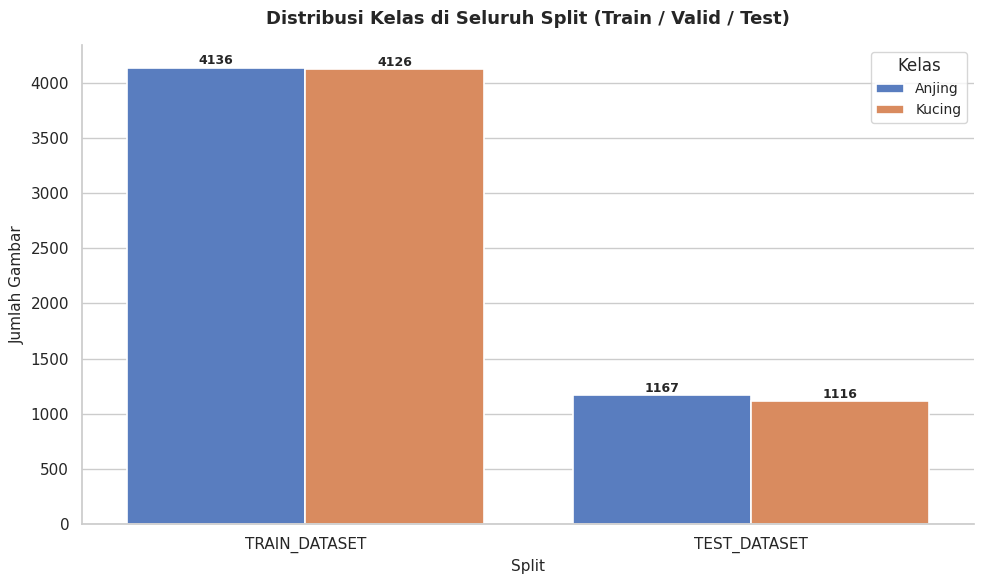

In [ ]:
# Tentukan tema chart
sns.set_theme(style="whitegrid", palette="muted")

# Tentukan ukuran chart
fig, ax = plt.subplots(figsize=(10, 6))

# Grouped bar chart setiap grup adalah satu split, setiap bar adalah satu kelas
splits  = [row["Split"]  for row in data_long]
kelas   = [row["Kelas"]  for row in data_long]
jumlah  = [row["Jumlah"] for row in data_long]

sns.barplot(
    x=splits,
    y=jumlah,
    hue=kelas,
    ax=ax,
    edgecolor="white",
    linewidth=1.2
)

# Tambahkan angka di atas setiap bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2,
            f"{int(height)}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

ax.set_title("Distribusi Kelas di Seluruh Split (Train / Valid / Test)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Split", fontsize=11)
ax.set_ylabel("Jumlah Gambar", fontsize=11)
ax.legend(title="Kelas", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Diskusi tentang dataset
print("=" * 55)
print(f"{'🔍 DISKUSI: APAKAH DATASET INI SEHAT?':^55}")
print("=" * 55)

semua_sehat = True

for split, data in distribusi.items():
    total_split = sum(data.values())
    maks        = max(data, key=data.get)
    minimum     = min(data, key=data.get)
    rasio       = data[maks] / data[minimum] if data[minimum] > 0 else float("inf")

    if rasio <= 1.5:
        status = "✅ SEHAT"
    elif rasio <= 3.0:
        status = "⚠️  PERLU DIPERHATIKAN"
        semua_sehat = False
    else:
        status = "❌ TIDAK SEHAT"
        semua_sehat = False

    print(f"\n📂 {split.upper()}")
    print(f"   Rasio ketimpangan : {rasio:.2f}x  →  {status}")
    for kelas, jumlah in data.items():
        persen = (jumlah / total_split * 100) if total_split > 0 else 0
        print(f"   {kelas:<15} {jumlah:>5} gambar ({persen:.1f}%)")

print(f"\n{'=' * 55}")
if semua_sehat:
    print("🎉 Kesimpulan: Dataset ini SEHAT dan siap digunakan!")
else:
    print("⚠️  Kesimpulan: Dataset perlu penyesuaian sebelum dipakai.")
    print("   Solusi yang bisa diterapkan:")
    print("   1. Augmentasi data pada kelas yang kurang")
    print("   2. Oversampling (duplikasi data minoritas)")
    print("   3. Pengumpulan data tambahan")
print("=" * 55)

         🔍 DISKUSI: APAKAH DATASET INI SEHAT?          

📂 TRAIN_DATASET
   Rasio ketimpangan : 1.00x  →  ✅ SEHAT
   anjing           4136 gambar (50.1%)
   kucing           4126 gambar (49.9%)

📂 TEST_DATASET
   Rasio ketimpangan : 1.05x  →  ✅ SEHAT
   anjing           1167 gambar (51.1%)
   kucing           1116 gambar (48.9%)

🎉 Kesimpulan: Dataset ini SEHAT dan siap digunakan!


### **📏 Sesi 3: Analisis Dimensi & Rasio Aspek Gambar**

#### **Kenapa Ukuran Gambar Harus Seragam?**




Di dunia nyata, kita mengumpulkan gambar dari berbagai sumber (ada yang pakai HP mode portrait, kamera DSLR mode landscape, atau hasil download internet). Alhasil, resolusinya beda-beda (misal: $1920 \times 1080$, $720 \times 1280$, atau $500 \times 500$ piksel).

Namun, model Deep Learning/AI membutuhkan input matriks yang ukurannya seragam (misalnya semua gambar harus diubah ukurannya menjadi $224 \times 224$ atau $300 \times 300$ piksel sebelum masuk ke proses training). Jika ukurannya tidak sama, struktur jaringan saraf tiruan (arsitektur AI) tidak akan bisa memprosesnya.

**Bahaya Pemaksaan (Squashing)**

Untuk menyeragamkan ukuran gambar, kita biasanya melakukan proses Resize. Tapi kita harus hati-hati dengan aspek rasio (perbandingan lebar dan tinggi).Jika sebuah foto pemandangan yang sangat lebar (landscape) langsung dipaksa diperkecil menjadi kotak persegi ($224 \times 224$), objek di dalamnya akan mengalami Squashing (Gepeng/Penyet). Kucing yang tadinya gemuk bisa terlihat kurus meninggi, atau sebaliknya.

**Mengapa ini bahaya untuk AI?**

AI belajar dari bentuk visual. Jika bentuk visualnya hancur atau terdistorsi akibat resize yang dipaksakan, AI akan kesulitan mengenali ciri asli objek tersebut di dunia nyata.

**Solusi EDA di Sesi Ini:** Kita akan meng-ekstrak tinggi dan lebar dari seluruh gambar, lalu melihat sebarannya menggunakan grafik Scatter Plot. Dari sana, kita bisa menentukan nilai rata-rata ukuran gambar yang paling pas sebagai acuan resize yang aman untuk dataset kita.

#### **Ekstrak Ukuran Gambar**

##### **💻 Praktik 1: Ekstraksi Width & Height Seluruh Gambar**

Sebelum melatih AI, kita harus tahu ukuran gambar-gambar yang kita miliki.
Apakah semua gambar sudah seragam? Atau ada yang portrait, landscape, bahkan persegi?

Di praktik ini kita akan melakukan **looping ke seluruh gambar** di split Train
dan mengekstrak informasi **lebar (width)** dan **tinggi (height)** dari setiap
file menggunakan OpenCV tanpa membuka gambarnya secara visual satu per satu.

In [ ]:
# Kumpulkan path semua gambar dari seluruh kelas di split Train
semua_path_train = []

for kelas in kelas_list:
    path_kelas = os.path.join(DATASET_PATH, "train_dataset", kelas)
    for ekstensi in IMAGE_EXTENSIONS:
        semua_path_train += glob.glob(os.path.join(path_kelas, ekstensi))

print(f"✅ Total gambar yang akan dianalisis : {len(semua_path_train)}")
print(f"   Contoh path pertama : {semua_path_train[0]}")

✅ Total gambar yang akan dianalisis : 8262
   Contoh path pertama : /content/dataset/train_dataset/anjing/anjing1101.jpg


In [ ]:
# Ekstrak dimensi setiap gambar menggunakan OpenCV
list_width  = []
list_height = []
list_kelas  = []  # untuk pewarnaan di scatter plot nanti
gagal       = 0

print("⏳ Sedang membaca dimensi gambar...")

for path in semua_path_train:
    img = cv2.imread(path)

    if img is None:
        gagal += 1
        continue

    h, w = img.shape[:2]  # shape mengembalikan (height, width, channel)
    list_height.append(h)
    list_width.append(w)

    # Ambil nama kelas dari nama folder parent
    nama_kelas = os.path.basename(os.path.dirname(path))
    list_kelas.append(nama_kelas)

print(f"✅ Berhasil dibaca : {len(list_width)} gambar")
print(f"❌ Gagal dibaca   : {gagal} gambar")

⏳ Sedang membaca dimensi gambar...
✅ Berhasil dibaca : 8262 gambar
❌ Gagal dibaca   : 0 gambar


In [ ]:
# Ringkasan statistik dimensi
arr_width  = np.array(list_width)
arr_height = np.array(list_height)

print("📐 STATISTIK DIMENSI GAMBAR")
print("=" * 40)
print(f"{'':20} {'Width':>8} {'Height':>8}")
print("─" * 40)
print(f"{'Minimum':<20} {arr_width.min():>8} {arr_height.min():>8}")
print(f"{'Maksimum':<20} {arr_width.max():>8} {arr_height.max():>8}")
print(f"{'Rata-rata':<20} {arr_width.mean():>8.1f} {arr_height.mean():>8.1f}")
print(f"{'Median':<20} {np.median(arr_width):>8.1f} {np.median(arr_height):>8.1f}")
print("=" * 40)

📐 STATISTIK DIMENSI GAMBAR
                        Width   Height
────────────────────────────────────────
Minimum                    57       41
Maksimum                 1050      768
Rata-rata               399.8    355.6
Median                  431.0    374.0


#### **Visualisasi Persebaran Ukuran**

##### **💻 Praktik 2: Visualisasi Sebaran Dimensi dengan Scatter Plot**

Statistik rata-rata saja tidak cukup, kita perlu **melihat sebaran** seluruh
dimensi gambar secara visual. Mungkin saja rata-ratanya 500x500, tapi ternyata
ada gambar yang sangat kecil (100x100) dan ada yang sangat besar (2000x2000).

**Scatter Plot** adalah grafik yang tepat untuk ini. Setiap titik mewakili
satu gambar, dengan sumbu X adalah lebar (width) dan sumbu Y adalah tinggi (height).
Dari sebaran titik-titiknya, kita bisa langsung menangkap pola ukuran dataset kita.

In [ ]:
# Buat mapping warna untuk setiap kelas agar titiknya berwarna berbeda
palette     = ["#4C72B0", "#C44E52"]
kelas_unik  = sorted(set(list_kelas))
warna_map   = {kelas: palette[i % len(palette)] for i, kelas in enumerate(kelas_unik)}
warna_titik = [warna_map[k] for k in list_kelas]

print("✅ Mapping warna per kelas:")
for kelas, warna in warna_map.items():
    print(f"   {kelas:<15} → {warna}")

✅ Mapping warna per kelas:
   anjing          → #4C72B0
   kucing          → #C44E52


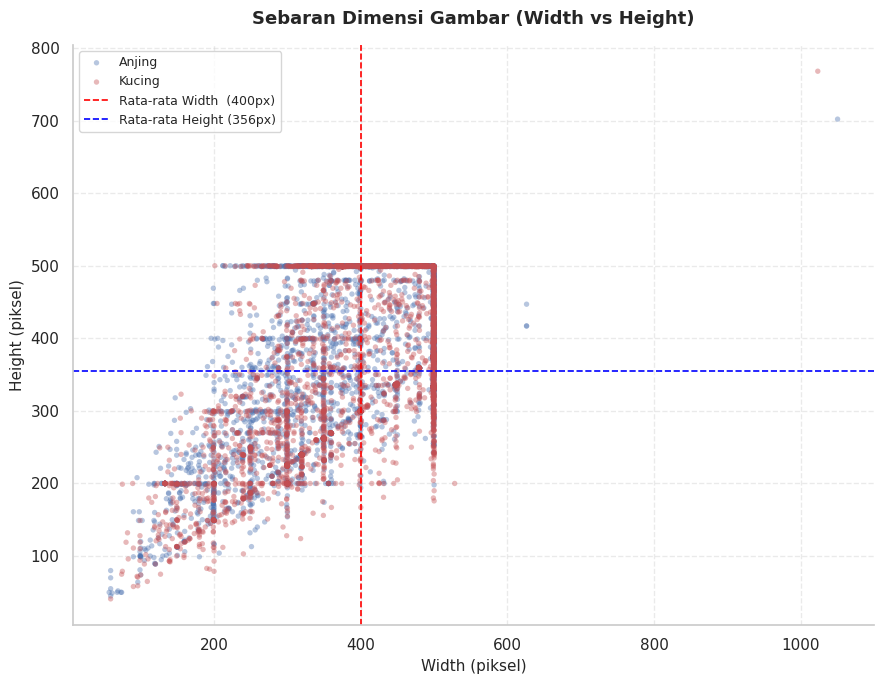

In [ ]:
# Buat Scatter Plot sebaran dimensi

# Ukuran visualisasi
fig, ax = plt.subplots(figsize=(9, 7))

# Plot setiap kelas secara terpisah agar legend muncul
for kelas, warna in warna_map.items():
    idx = [i for i, k in enumerate(list_kelas) if k == kelas]
    ax.scatter(
        [list_width[i]  for i in idx],
        [list_height[i] for i in idx],
        c=warna,
        label=kelas.capitalize(),
        alpha=0.4,
        s=15,
        edgecolors="none"
    )

# Garis bantu rata-rata (crosshair)
ax.axvline(arr_width.mean(),  color="red",  linestyle="--", linewidth=1.2, label=f"Rata-rata Width  ({arr_width.mean():.0f}px)")
ax.axhline(arr_height.mean(), color="blue", linestyle="--", linewidth=1.2, label=f"Rata-rata Height ({arr_height.mean():.0f}px)")

ax.set_title("Sebaran Dimensi Gambar (Width vs Height)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Width (piksel)", fontsize=11)
ax.set_ylabel("Height (piksel)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Hitung berapa persen gambar yang sudah berbentuk persegi (square)
toleransi   = 0.1  # toleransi 10% — dianggap persegi jika rasio width/height mendekati 1
rasio_aspek = arr_width / arr_height
is_square   = np.abs(rasio_aspek - 1.0) <= toleransi

print("🔍 ANALISIS POLA SEBARAN DIMENSI")
print("=" * 45)
print(f"   Gambar berbentuk persegi (±10%)  : {is_square.sum():>5} ({is_square.mean()*100:.1f}%)")
print(f"   Gambar landscape (width > height): {(arr_width > arr_height).sum():>5} ({(arr_width > arr_height).mean()*100:.1f}%)")
print(f"   Gambar portrait (height > width) : {(arr_height > arr_width).sum():>5} ({(arr_height > arr_width).mean()*100:.1f}%)")
print("=" * 45)

🔍 ANALISIS POLA SEBARAN DIMENSI
   Gambar berbentuk persegi (±10%)  :  1353 (16.4%)
   Gambar landscape (width > height):  5672 (68.7%)
   Gambar portrait (height > width) :  2560 (31.0%)


#### **Berapa Ukuran Resize?**

##### **💻 Praktik 3: Menentukan Ukuran Resize yang Optimal**

Dari Scatter Plot tadi kita sudah bisa melihat sebaran dimensi gambar secara visual.
Sekarang kita akan menerjemahkan insight tersebut menjadi **keputusan teknis** —
berapa ukuran resize yang paling aman dan optimal untuk dataset kita?

Ada dua pendekatan yang umum digunakan:
- **Rata-rata dimensi** → Ukuran yang paling "tengah" dari seluruh dataset
- **Ukuran standar Deep Learning** → Ukuran baku yang umum dipakai model AI
  seperti `224×224` (VGG, ResNet), `300×300` (SSD), atau `640×640` (YOLO)

Kita akan membandingkan keduanya dan memilih yang paling cocok.

In [ ]:
# Hitung kandidat ukuran resize dari data

# Kandidat ukuran standar yang umum dipakai di Deep Learning
UKURAN_STANDAR = [224, 300, 416, 512, 640]

# Hitung rata-rata dan median dimensi dataset kita
rata_width  = int(arr_width.mean())
rata_height = int(arr_height.mean())
med_width   = int(np.median(arr_width))
med_height  = int(np.median(arr_height))

print("📐 KANDIDAT UKURAN RESIZE")
print("=" * 45)
print(f"   Berdasarkan rata-rata  : {rata_width} x {rata_height} px")
print(f"   Berdasarkan median     : {med_width} x {med_height} px")
print()
print(f"   Ukuran standar Deep Learning:")
for ukuran in UKURAN_STANDAR:
    print(f"   - {ukuran} x {ukuran} px")
print("=" * 45)

📐 KANDIDAT UKURAN RESIZE
   Berdasarkan rata-rata  : 399 x 355 px
   Berdasarkan median     : 431 x 374 px

   Ukuran standar Deep Learning:
   - 224 x 224 px
   - 300 x 300 px
   - 416 x 416 px
   - 512 x 512 px
   - 640 x 640 px


In [ ]:
# Hitung loss informasi jika di-resize ke setiap ukuran standar

# Untuk setiap ukuran standar, hitung berapa banyak gambar yang akan
# mengalami upscale (diperbesar) vs downscale (diperkecil)
print("📊 ANALISIS DAMPAK RESIZE PER UKURAN STANDAR")
print("=" * 55)
print(f"{'Ukuran':<12} {'Upscale':>10} {'Downscale':>10} {'Squash Risk':>12}")
print("─" * 55)

for ukuran in UKURAN_STANDAR:
    # Gambar yang lebih kecil dari ukuran target → akan diperbesar (upscale)
    upscale   = np.sum((arr_width < ukuran) | (arr_height < ukuran))
    # Gambar yang lebih besar dari ukuran target → akan diperkecil (downscale)
    downscale = np.sum((arr_width > ukuran) | (arr_height > ukuran))

    # Squash risk: gambar yang rasio aspeknya jauh dari 1:1
    # saat dipaksa menjadi persegi
    squash = np.sum(np.abs(rasio_aspek - 1.0) > 0.3)

    print(f"{ukuran}x{ukuran:<6} {upscale:>10} {downscale:>10} {squash:>12}")

print("=" * 55)
print(f"   Total gambar dianalisis : {len(list_width)}")

📊 ANALISIS DAMPAK RESIZE PER UKURAN STANDAR
Ukuran          Upscale  Downscale  Squash Risk
───────────────────────────────────────────────────────
224x224          1190       7719         4633
300x300          2601       6846         4633
416x416          7248       5362         4633
512x512          8260          6         4633
640x640          8260          2         4633
   Total gambar dianalisis : 8262


In [ ]:
# Rekomendasi ukuran resize akhir

# Cari ukuran standar yang paling dekat dengan median dataset kita
median_sisi = (med_width + med_height) / 2
rekomendasi = min(UKURAN_STANDAR, key=lambda x: abs(x - median_sisi))

print("=" * 55)
print(f"{'💡 REKOMENDASI UKURAN RESIZE':^55}")
print("=" * 55)
print(f"\n   Median dimensi dataset  : {med_width} x {med_height} px")
print(f"   Ukuran standar terdekat : {rekomendasi} x {rekomendasi} px")
print()
print(f"   ✅ Rekomendasi final: gunakan {rekomendasi}x{rekomendasi} px")
print()
print("   Catatan:")
print("   - Gunakan padding (letterbox) saat resize agar objek")
print("     tidak terdistorsi akibat squashing.")
print("   - Hindari upscale berlebihan karena dapat menurunkan")
print("     kualitas fitur yang dipelajari AI.")
print("=" * 55)

              💡 REKOMENDASI UKURAN RESIZE              

   Median dimensi dataset  : 431 x 374 px
   Ukuran standar terdekat : 416 x 416 px

   ✅ Rekomendasi final: gunakan 416x416 px

   Catatan:
   - Gunakan padding (letterbox) saat resize agar objek
     tidak terdistorsi akibat squashing.
   - Hindari upscale berlebihan karena dapat menurunkan
     kualitas fitur yang dipelajari AI.


### **🗑️ Sesi 4: Deteksi Kualitas "Sampah" Visual & Pipeline Pembersihan**

#### **Bahaya Gambar Corrupt (Rusak)**


Saat kita mengunduh ribuan gambar dari internet, kadang ada file yang tidak terunduh dengan sempurna. File-nya ada di dalam folder, ekstensinya benar .jpg, tapi datanya rusak atau terpotong (corrupt).

**Apa dampaknya buat AI?**

Proses pelatihan AI (training loop) itu berjalan secara berurutan. Jika di tengah jalan kodingan kita mencoba membuka gambar yang corrupt ini, program Python akan langsung mengalami crash, error, dan proses training yang sudah berjalan berjam-jam bisa berhenti tiba-tiba.

Oleh karena itu, kita wajib melakukan screening awal menggunakan sistem penanganan error (**Try-Except**) untuk mendeteksi file rusak ini dan menyingkirkannya.

**Anomali Piksel (Gambar Terlalu Gelap/Terang)**

Bukan cuma file rusak yang bisa mengacaukan AI, tapi juga gambar yang kualitas visualnya buruk. Contohnya adalah gambar yang hitam pekat (karena kamera tertutup atau foto diambil malam hari tanpa cahaya).

**Mengapa ini masalah?**

Secara digital, gambar adalah kumpulan angka piksel dari skala 0 (Hitam) sampai 255 (Putih). Jika sebuah gambar terlalu gelap dan didominasi angka mendekati 0, AI tidak akan bisa mengekstrak fitur apa pun (tidak ada bentuk mata, kuping, atau tekstur yang kelihatan). Gambar seperti ini hanya akan menjadi "beban" dan merusak kestabilan belajar AI.

**Solusi di Sesi Ini**:

Kita akan menggunakan NumPy untuk menghitung rata-rata nilai piksel dari setiap gambar. Jika rata-ratanya di bawah ambang batas (threshold) yang kita tentukan, program akan otomatis menandainya sebagai "Sampah Visual" untuk kemudian dihapus dari folder.

#### **Deteksi Gambar Corrupt**

##### **💻 Praktik 1: Deteksi Gambar Corrupt dengan Try-Except**

Dari ribuan gambar yang kita punya, hampir pasti ada beberapa file yang **corrupt**
(rusak), misalnya filenya ada di folder, ekstensinya benar `.jpg` atau `.png`, tapi
datanya terpotong atau tidak bisa dibaca sama sekali.

Jika file rusak ini ikut masuk ke proses training AI, program akan **crash
secara tiba-tiba** di tengah jalan dan menghentikan proses yang sudah berjalan
berjam-jam.

Solusinya adalah mekanisme **Try-Except** di mana kita *mencoba* membuka setiap file,
dan jika gagal, kita *tangkap* errornya dan catat file tersebut sebagai sampah
tanpa menghentikan program.

In [ ]:
# Kumpulkan semua path gambar dari seluruh split

# Kali ini kita scan seluruh dataset (train + valid + test)
# karena gambar corrupt bisa ada di mana saja
semua_path_dataset = []

for split in split_folders:
    for kelas in kelas_list:
        path_kelas = os.path.join(DATASET_PATH, split, kelas)
        if not os.path.exists(path_kelas):
            continue
        for ekstensi in IMAGE_EXTENSIONS:
            semua_path_dataset += glob.glob(os.path.join(path_kelas, ekstensi))

print(f"✅ Total file yang akan diperiksa : {len(semua_path_dataset)}")

✅ Total file yang akan diperiksa : 10545


In [ ]:
# Deteksi file corrupt menggunakan Try-Except

list_corrupt = []  # menyimpan path gambar yang rusak

print("⏳ Memeriksa integritas file gambar...")

for path in semua_path_dataset:
    try:
        img = cv2.imread(path)

        # cv2.imread() tidak selalu raise error saat file rusak —
        # terkadang ia mengembalikan None
        if img is None:
            raise ValueError("File terbaca sebagai None")

        # Cek tambahan: pastikan gambar punya dimensi yang valid
        h, w = img.shape[:2]
        if h == 0 or w == 0:
            raise ValueError("Dimensi gambar tidak valid (0px)")

    except Exception as e:
        list_corrupt.append({
            "path"  : path,
            "error" : str(e)
        })

print(f"✅ File normal  : {len(semua_path_dataset) - len(list_corrupt)}")
print(f"❌ File corrupt : {len(list_corrupt)}")

⏳ Memeriksa integritas file gambar...
✅ File normal  : 10545
❌ File corrupt : 0


In [ ]:
# Tampilkan daftar file corrupt yang ditemukan

if len(list_corrupt) == 0:
    print("🎉 Tidak ada file corrupt yang ditemukan!")
else:
    print(f"🗑️  DAFTAR FILE CORRUPT ({len(list_corrupt)} file):")
    print("=" * 60)
    for i, item in enumerate(list_corrupt, 1):
        nama_file = os.path.basename(item["path"])
        print(f"   {i:>3}. {nama_file:<30} | {item['error']}")
    print("=" * 60)

🎉 Tidak ada file corrupt yang ditemukan!


#### **Deteksi Gambar Blank/Gelap**

##### **💻 Praktik 2: Deteksi Gambar Gelap/Blank dengan NumPy**

Selain file corrupt, ada jenis "sampah visual" lain yang lebih sulit terdeteksi
karena **filenya tidak rusak** — gambarnya bisa dibuka dengan normal, tapi
isinya tidak berguna untuk AI.

Contohnya:
- 📷 Gambar **terlalu gelap** → foto diambil di ruangan gelap tanpa cahaya
- ⬜ Gambar **blank/putih polos** → file kosong atau gagal diunduh dengan benar

Secara digital, gambar adalah kumpulan angka piksel dari skala **0 (hitam)
hingga 255 (putih)**. Kita bisa memanfaatkan `NumPy` untuk menghitung
**rata-rata nilai piksel** setiap gambar — jika nilainya terlalu rendah
(mendekati 0) atau terlalu tinggi (mendekati 255), gambar tersebut dianggap anomali.

In [ ]:
# Tentukan threshold anomali

# Threshold rata-rata piksel untuk menentukan anomali
# Nilai piksel berkisar 0–255
THRESHOLD_GELAP  = 20   # rata-rata piksel di bawah ini → terlalu gelap
THRESHOLD_TERANG = 240  # rata-rata piksel di atas ini  → terlalu terang/blank

print("⚙️  Konfigurasi threshold anomali:")
print(f"   Gambar terlalu gelap  : rata-rata piksel < {THRESHOLD_GELAP}")
print(f"   Gambar terlalu terang : rata-rata piksel > {THRESHOLD_TERANG}")
print()
print("💡 Nilai ini bisa disesuaikan tergantung karakteristik dataset kamu.")

⚙️  Konfigurasi threshold anomali:
   Gambar terlalu gelap  : rata-rata piksel < 20
   Gambar terlalu terang : rata-rata piksel > 240

💡 Nilai ini bisa disesuaikan tergantung karakteristik dataset kamu.


In [ ]:
# Scan seluruh gambar & hitung rata-rata piksel

list_anomali = []  # menyimpan gambar yang terdeteksi anomali

# Gunakan hanya gambar yang tidak corrupt
path_normal = [
    p for p in semua_path_dataset
    if p not in [item["path"] for item in list_corrupt]
]

print(f"⏳ Menganalisis {len(path_normal)} gambar...")

for path in path_normal:
    img = cv2.imread(path)

    if img is None:
        continue

    # Konversi ke grayscale agar perhitungan rata-rata lebih sederhana
    # (1 channel, bukan 3 channel RGB)
    img_gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rata_piksel = np.mean(img_gray)

    if rata_piksel < THRESHOLD_GELAP:
        list_anomali.append({
            "path"        : path,
            "rata_piksel" : rata_piksel,
            "tipe"        : "Terlalu Gelap"
        })
    elif rata_piksel > THRESHOLD_TERANG:
        list_anomali.append({
            "path"        : path,
            "rata_piksel" : rata_piksel,
            "tipe"        : "Terlalu Terang / Blank"
        })

print(f"✅ Scan selesai!")
print(f"⚠️  Anomali ditemukan : {len(list_anomali)} gambar")

⏳ Menganalisis 10545 gambar...
✅ Scan selesai!
⚠️  Anomali ditemukan : 13 gambar


In [ ]:
# Ringkasan hasil deteksi anomali

gelap  = [x for x in list_anomali if x["tipe"] == "Terlalu Gelap"]
terang = [x for x in list_anomali if x["tipe"] == "Terlalu Terang / Blank"]

print("📊 RINGKASAN DETEKSI ANOMALI PIKSEL")
print("=" * 45)
print(f"   Gambar terlalu gelap         : {len(gelap):>5}")
print(f"   Gambar terlalu terang/blank  : {len(terang):>5}")
print(f"   {'─' * 35}")
print(f"   Total anomali                : {len(list_anomali):>5}")
print(f"   Total gambar diperiksa       : {len(path_normal):>5}")
print(f"   Persentase anomali           : {len(list_anomali)/len(path_normal)*100:>4.2f}%")
print("=" * 45)

📊 RINGKASAN DETEKSI ANOMALI PIKSEL
   Gambar terlalu gelap         :     1
   Gambar terlalu terang/blank  :    12
   ───────────────────────────────────
   Total anomali                :    13
   Total gambar diperiksa       : 10545
   Persentase anomali           : 0.12%


#### **Visualisasi Gambar Anomali**

##### **💻 Praktik 3: Visualisasi Gambar Anomali yang Ditemukan**

Sebelum kita hapus gambar-gambar bermasalah tersebut, ada satu langkah penting
yang tidak boleh dilewatkan, yaitu **verifikasi visual**.

Kita harus melihat sendiri gambar-gambar yang akan dihapus untuk memastikan
program kita benar-benar mendeteksi "sampah" dan bukan gambar yang sebenarnya
masih berguna. Menghapus data tanpa verifikasi adalah kesalahan fatal yang
bisa mengurangi ukuran dataset secara tidak sengaja.

Di sini kita akan menampilkan **5 gambar paling gelap** dan
**5 gambar paling terang** yang ditemukan oleh program kita.

In [ ]:
# Urutkan data anomali berdasarkan tingkat keparahan

# Urutkan gambar gelap dari yang paling gelap (rata-rata piksel paling kecil)
gelap_sorted  = sorted(gelap,  key=lambda x: x["rata_piksel"])
# Urutkan gambar terang dari yang paling terang (rata-rata piksel paling besar)
terang_sorted = sorted(terang, key=lambda x: x["rata_piksel"], reverse=True)

# Ambil 5 terparah dari masing-masing kategori
top_gelap  = gelap_sorted[:5]
top_terang = terang_sorted[:5]

print(f"🔍 5 Gambar Paling Gelap:")
for i, item in enumerate(top_gelap, 1):
    print(f"   {i}. {os.path.basename(item['path']):<30} rata-rata piksel: {item['rata_piksel']:.2f}")

print(f"\n🔍 5 Gambar Paling Terang/Blank:")
for i, item in enumerate(top_terang, 1):
    print(f"   {i}. {os.path.basename(item['path']):<30} rata-rata piksel: {item['rata_piksel']:.2f}")

🔍 5 Gambar Paling Gelap:
   1. anjing4038.jpg                 rata-rata piksel: 7.69

🔍 5 Gambar Paling Terang/Blank:
   1. anjing4010.jpg                 rata-rata piksel: 247.89
   2. kucing4092.jpg                 rata-rata piksel: 246.51
   3. kucing1093.jpg                 rata-rata piksel: 246.51
   4. kucing4059.jpg                 rata-rata piksel: 245.59
   5. kucing4007.jpg                 rata-rata piksel: 245.22


/tmp/ipykernel_2210/2476667374.py:37: UserWarning: Glyph 127761 (\N{NEW MOON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127761 (\N{NEW MOON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


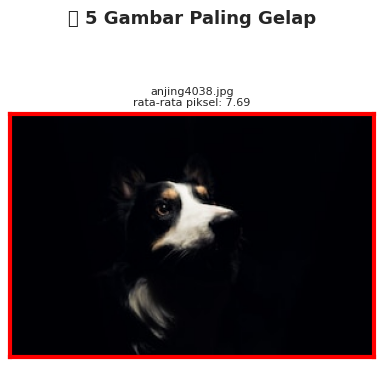

In [ ]:
# Visualisasi 5 gambar paling gelap

def tampilkan_anomali(list_gambar, judul_utama, warna_border):
    """
    Menampilkan kolase gambar anomali beserta informasi rata-rata pikselnya.
    """
    n = len(list_gambar)
    if n == 0:
        print(f"✅ Tidak ada gambar dalam kategori '{judul_utama}'.")
        return

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    fig.suptitle(judul_utama, fontsize=13, fontweight="bold", y=1.02)

    # Pastikan axes selalu berupa list meski hanya 1 gambar
    if n == 1:
        axes = [axes]

    for ax, item in zip(axes, list_gambar):
        img_bgr = cv2.imread(item["path"])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        ax.imshow(img_rgb)
        ax.set_title(
            f"{os.path.basename(item['path'])}\nrata-rata piksel: {item['rata_piksel']:.2f}",
            fontsize=8, pad=6
        )

        # Tambahkan border berwarna sesuai kategori anomali
        for spine in ax.spines.values():
            spine.set_edgecolor(warna_border)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# Tampilkan 5 gambar paling gelap
tampilkan_anomali(top_gelap, "🌑 5 Gambar Paling Gelap", warna_border="red")

/tmp/ipykernel_2210/2476667374.py:37: UserWarning: Glyph 11036 (\N{WHITE LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11036 (\N{WHITE LARGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


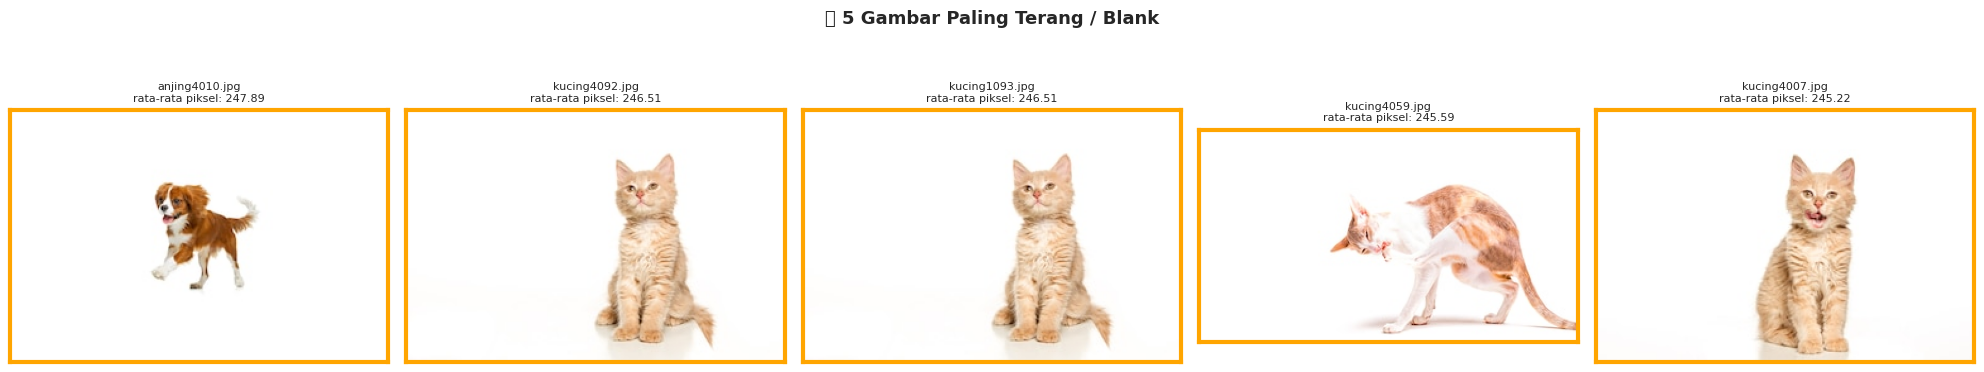

In [ ]:
# Visualisasi 5 gambar paling terang/blank

# Tampilkan 5 gambar paling terang/blank
tampilkan_anomali(top_terang, "⬜ 5 Gambar Paling Terang / Blank", warna_border="orange")

In [ ]:
# Konfirmasi sebelum lanjut ke penghapusan

total_akan_dihapus = len(list_corrupt) + len(list_anomali)

print("=" * 55)
print(f"{'⚠️  RINGKASAN SEBELUM PENGHAPUSAN':^55}")
print("=" * 55)
print(f"   File corrupt           : {len(list_corrupt):>5} file")
print(f"   Gambar anomali piksel  : {len(list_anomali):>5} file")
print(f"   {'─' * 40}")
print(f"   Total akan dihapus     : {total_akan_dihapus:>5} file")
print(f"   Total dataset awal     : {len(semua_path_dataset):>5} file")
print(f"   Sisa setelah bersih    : {len(semua_path_dataset) - total_akan_dihapus:>5} file")
print("=" * 55)
print()
print("👀 Pastikan kamu sudah memverifikasi gambar-gambar di atas")
print("   sebelum menjalankan Praktik 4 (penghapusan otomatis)!")

           ⚠️  RINGKASAN SEBELUM PENGHAPUSAN           
   File corrupt           :     0 file
   Gambar anomali piksel  :    13 file
   ────────────────────────────────────────
   Total akan dihapus     :    13 file
   Total dataset awal     : 10545 file
   Sisa setelah bersih    : 10532 file

👀 Pastikan kamu sudah memverifikasi gambar-gambar di atas
   sebelum menjalankan Praktik 4 (penghapusan otomatis)!


#### **Penghapusan Sampah**

##### **💻 Praktik 4: Penghapusan Otomatis File Sampah dengan os.remove()**

Ini adalah langkah terakhir dari pipeline pembersihan dataset kita.
Setelah kita sudah **memverifikasi secara visual** di Praktik 3, sekarang
kita akan memerintahkan Python untuk **menghapus semua file sampah secara otomatis**.

⚠️ **PERINGATAN PENTING:**
> Cell ini bersifat **irreversible** atau file yang sudah dihapus tidak bisa
> dikembalikan. Pastikan kamu sudah:
> 1. Memverifikasi gambar anomali di Praktik 3
> 2. Membuat **backup dataset** sebelum menjalankan cell ini
> 3. Benar-benar yakin dengan threshold yang sudah ditentukan di Praktik 2

In [ ]:
# Gabungkan semua path sampah yang akan dihapus

# Gabungkan path dari dua sumber:
# 1. File corrupt yang ditemukan di Praktik 1
# 2. Gambar anomali piksel yang ditemukan di Praktik 2
path_corrupt = [item["path"] for item in list_corrupt]
path_anomali = [item["path"] for item in list_anomali]

semua_sampah = list(set(path_corrupt + path_anomali))  # set() untuk hindari duplikat

print(f"🗑️  Total file yang siap dihapus : {len(semua_sampah)}")
print()
print("   Rincian:")
print(f"   - File corrupt          : {len(path_corrupt)}")
print(f"   - Gambar anomali piksel : {len(path_anomali)}")

🗑️  Total file yang siap dihapus : 13

   Rincian:
   - File corrupt          : 0
   - Gambar anomali piksel : 13


In [ ]:
# Dry run: simulasi penghapusan tanpa benar-benar menghapus

# DRY RUN — jalankan ini dulu sebelum penghapusan sesungguhnya
# untuk memastikan daftar file yang akan dihapus sudah benar

print("🔍 DRY RUN — Simulasi Penghapusan (tidak ada file yang dihapus)")
print("=" * 60)

for i, path in enumerate(semua_sampah, 1):
    nama_file  = os.path.basename(path)
    nama_split = path.replace(DATASET_PATH, "").split(os.sep)[1]
    nama_kelas = path.replace(DATASET_PATH, "").split(os.sep)[2]
    print(f"   {i:>3}. [{nama_split}/{nama_kelas}] {nama_file}")

print("=" * 60)
print(f"✅ Dry run selesai. {len(semua_sampah)} file akan dihapus jika kamu")
print(f"   menjalankan Cell berikutnya.")

🔍 DRY RUN — Simulasi Penghapusan (tidak ada file yang dihapus)
     1. [train_dataset/kucing] kucing4092.jpg
     2. [train_dataset/anjing] anjing4038.jpg
     3. [test_dataset/anjing] anjing1095.jpg
     4. [train_dataset/anjing] anjing3986.jpg
     5. [train_dataset/kucing] kucing4007.jpg
     6. [train_dataset/anjing] anjing4003.jpg
     7. [test_dataset/kucing] kucing1093.jpg
     8. [test_dataset/kucing] kucing1074.jpg
     9. [train_dataset/kucing] kucing4059.jpg
    10. [train_dataset/anjing] anjing4010.jpg
    11. [test_dataset/kucing] kucing1099.jpg
    12. [train_dataset/kucing] kucing4024.jpg
    13. [train_dataset/anjing] anjing4008.jpg
✅ Dry run selesai. 13 file akan dihapus jika kamu
   menjalankan Cell berikutnya.


In [ ]:
# Eksekusi penghapusan sesungguhnya

# ============================================================
# ⚠️  BAHAYA: Cell ini akan MENGHAPUS FILE SECARA PERMANEN
# Jalankan hanya jika kamu sudah:
# 1. Menjalankan Dry Run di Cell sebelumnya
# 2. Memverifikasi gambar di Praktik 3
# 3. Membuat backup dataset
# ============================================================

berhasil_hapus = 0
gagal_hapus    = []

print("🗑️  Memulai proses penghapusan...")
print("=" * 55)

for path in semua_sampah:
    try:
        os.remove(path)
        berhasil_hapus += 1
        print(f"   ✅ Dihapus : {os.path.basename(path)}")
    except Exception as e:
        gagal_hapus.append({"path": path, "error": str(e)})
        print(f"   ❌ Gagal   : {os.path.basename(path)} → {str(e)}")

print("=" * 55)
print(f"✅ Berhasil dihapus : {berhasil_hapus} file")
print(f"❌ Gagal dihapus    : {len(gagal_hapus)} file")

🗑️  Memulai proses penghapusan...
   ✅ Dihapus : kucing4092.jpg
   ✅ Dihapus : anjing4038.jpg
   ✅ Dihapus : anjing1095.jpg
   ✅ Dihapus : anjing3986.jpg
   ✅ Dihapus : kucing4007.jpg
   ✅ Dihapus : anjing4003.jpg
   ✅ Dihapus : kucing1093.jpg
   ✅ Dihapus : kucing1074.jpg
   ✅ Dihapus : kucing4059.jpg
   ✅ Dihapus : anjing4010.jpg
   ✅ Dihapus : kucing1099.jpg
   ✅ Dihapus : kucing4024.jpg
   ✅ Dihapus : anjing4008.jpg
✅ Berhasil dihapus : 13 file
❌ Gagal dihapus    : 0 file


In [ ]:
# Verifikasi akhir dataset setelah pembersihan

# Hitung ulang total gambar setelah pembersihan
print("=" * 55)
print(f"{'📊 LAPORAN AKHIR DATASET':^55}")
print("=" * 55)

total_akhir = 0

for split in split_folders:
    total_split = 0
    path_split  = os.path.join(DATASET_PATH, split)

    if not os.path.exists(path_split):
        continue

    print(f"\n📂 {split.upper()}")
    for kelas in kelas_list:
        path_kelas = os.path.join(path_split, kelas)
        jumlah     = hitung_gambar_dalam_folder(path_kelas)
        total_split += jumlah
        print(f"   {kelas:<15} : {jumlah} gambar")

    print(f"   {'─' * 30}")
    print(f"   Subtotal       : {total_split} gambar")
    total_akhir += total_split

print(f"\n{'=' * 55}")
print(f"   Dataset awal   : {len(semua_path_dataset)} gambar")
print(f"   File dihapus   : {berhasil_hapus} file")
print(f"   Dataset bersih : {total_akhir} gambar")
print(f"{'=' * 55}")
print()
print("🎉 Pipeline pembersihan dataset selesai!")
print("   Dataset kamu siap untuk masuk ke tahap Training AI.")

                📊 LAPORAN AKHIR DATASET                

📂 TRAIN_DATASET
   anjing          : 4131 gambar
   kucing          : 4122 gambar
   ──────────────────────────────
   Subtotal       : 8253 gambar

📂 TEST_DATASET
   anjing          : 1166 gambar
   kucing          : 1113 gambar
   ──────────────────────────────
   Subtotal       : 2279 gambar

   Dataset awal   : 10545 gambar
   File dihapus   : 13 file
   Dataset bersih : 10532 gambar

🎉 Pipeline pembersihan dataset selesai!
   Dataset kamu siap untuk masuk ke tahap Training AI.


##